# Reproduce selected paper figures

This notebook recreates **Fig. 2b, Fig. 2c, Fig. 2e, Fig. 3b, Fig. 3c,
Fig. 3d, Fig. 3e, Fig. 3f, and Fig. 3h** from the saved model, labels,
and analysis tables. Every plot is displayed inline and retained in the
committed notebook; no figure file is written to disk.

The calculations follow
`Dog_project/0909-Generate-plot-for-paper.ipynb`, with duplicated exploratory
cells removed and paths made configurable.

## Data locations

All inputs used by this notebook are included in the repository. By default,
paper-analysis assets are loaded from `Figure_data/` at the repository root.
Set `DAP_FIGURE_DATA` only if you want to use a copy at another location.

The bundled Fig. 2c directory contains the archived 10-output model and its
matching legacy 100-PC matrix. Fig. 2c uses the same 80/20 split with
`random_state=42` as the source notebook and does not retrain the model.

In [1]:
from pathlib import Path
from collections import Counter
import os
import platform
import warnings

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.exceptions import InconsistentVersionWarning
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

# Resolve the repository whether the kernel starts in the repository root or
# in its notebooks directory.
candidates = [Path.cwd(), Path.cwd().parent]
REPO_ROOT = next((p for p in candidates if (p / "pyproject.toml").exists()), Path.cwd())
FIGURE_DATA = Path(os.environ.get("DAP_FIGURE_DATA", REPO_ROOT / "Figure_data"))

sns.set_theme(style="ticks", context="notebook")
mpl.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.titleweight": "bold",
    "font.family": "DejaVu Sans",
})

print(f"Python:          {platform.python_version()}")
print(f"scikit-learn:   {sklearn.__version__}")
print(f"Repository:      {REPO_ROOT}")
print(f"Figure data:     {FIGURE_DATA}")

Python:          3.9.25
scikit-learn:   1.6.1
Repository:      /scratch/gpfs/AKEY/yb2807/DAP_breed_prediction
Figure data:     /scratch/gpfs/AKEY/yb2807/tmp/dap-figure-data.G0Xx2h


## Shared prediction functions

The threshold conversion and strict/loose metrics below are the same rules
used in the original analysis. A score vector is called purebred when its
maximum exceeds the purity threshold; otherwise its two largest components
form a 50/50 mixed-breed prediction.

In [2]:
def transform_prediction(y_pred, pure_threshold):
    transformed = []
    for row in np.asarray(y_pred):
        output = np.zeros_like(row, dtype=float)
        if row.max() > pure_threshold:
            output[np.argmax(row)] = 1.0
        else:
            output[np.argsort(row)[-2:]] = 0.5
        transformed.append(output)
    transformed = np.asarray(transformed)
    if not np.allclose(transformed.sum(axis=1), 1.0):
        raise ValueError("Transformed prediction rows must sum to one")
    return transformed


def prediction_metrics(y_pred, y_true, pure_threshold):
    transformed = transform_prediction(y_pred, pure_threshold)
    truth = y_true.to_numpy()
    strict_correct = np.all(transformed == truth, axis=1)
    loose_correct = np.asarray([
        bool(set(np.flatnonzero(t)) & set(np.flatnonzero(p)))
        for t, p in zip(truth, transformed)
    ])
    true_is_pure = truth.max(axis=1) == 1.0
    pred_is_pure = transformed.max(axis=1) == 1.0
    metadata = pd.DataFrame({
        "strict_wrong": ~strict_correct,
        "loose_wrong": ~loose_correct,
        "puremix_wrong": true_is_pure != pred_is_pure,
    }, index=y_true.index)
    return strict_correct.mean(), loose_correct.mean(), (true_is_pure == pred_is_pure).mean(), metadata


def threshold_search(y_pred, y_true):
    thresholds = np.arange(0.0, 1.01, 0.01)
    values = [prediction_metrics(y_pred, y_true, theta)[:3] for theta in thresholds]
    strict, loose, puremix = map(np.asarray, zip(*values))
    return thresholds, strict, loose, puremix


def best_threshold(thresholds, strict, loose):
    candidates = np.flatnonzero(loose == loose.max())
    strict_best = strict[candidates].max()
    return thresholds[candidates[strict[candidates] == strict_best][-1]]


def class_label(row):
    return "|".join(sorted(row.index[row.to_numpy() > 0].tolist()))


def sorted_class_labels(labels):
    return sorted(labels, key=lambda value: (value.count("|") + 1, value))


def plot_prediction_map(y_true, y_pred, theta, metadata, title):
    transformed = transform_prediction(y_pred, theta)
    true_labels = y_true.apply(class_label, axis=1)
    pred_labels = pd.DataFrame(
        transformed, index=y_true.index, columns=y_true.columns
    ).apply(class_label, axis=1)

    labels = sorted_class_labels(set(true_labels) | set(pred_labels))
    label_index = {label: i for i, label in enumerate(labels)}
    matrix = confusion_matrix(true_labels, pred_labels, labels=labels)
    true_classes = set(true_labels)
    pred_classes = set(pred_labels)

    breed_number = {breed: i + 1 for i, breed in enumerate(y_true.columns)}
    def short_label(label):
        return "/".join(str(breed_number[breed]) for breed in label.split("|"))
    def overlaps(a, b):
        return bool(set(a.split("|")) & set(b.split("|")))

    n_classes = len(labels)
    fig_size = max(11, 0.27 * n_classes)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    ax.set(xlim=(0, n_classes), ylim=(n_classes, 0))

    wrong_cells = set()
    for wrong, true, pred in zip(metadata["strict_wrong"], true_labels, pred_labels):
        if wrong:
            wrong_cells.add((label_index[true], label_index[pred]))

    for i, true in enumerate(labels):
        for j, pred in enumerate(labels):
            if true == pred:
                facecolor = "#159f78"
            elif overlaps(true, pred):
                facecolor = "#edae2f"
            else:
                facecolor = "#75c9e6"
            ax.add_patch(Rectangle((j, i), 1, 1, facecolor=facecolor,
                                   edgecolor="#65727a", linewidth=0.45))
            if matrix[i, j]:
                ax.text(j + 0.5, i + 0.5, str(matrix[i, j]),
                        ha="center", va="center", fontsize=6.5)

    for i, j in wrong_cells:
        ax.add_patch(Rectangle((j, i), 1, 1, fill=False,
                               edgecolor="#e31a1c", linewidth=1.5))

    tick_labels = []
    for label in labels:
        suffix = "*" if label not in true_classes else ""
        tick_labels.append(short_label(label) + suffix)
    y_tick_labels = [
        ("+" if label not in pred_classes else "") + short_label(label)
        for label in labels
    ]
    ax.set_xticks(np.arange(n_classes) + 0.5, tick_labels, rotation=90, fontsize=6)
    ax.set_yticks(np.arange(n_classes) + 0.5, y_tick_labels, fontsize=6)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title, pad=28)
    ax.legend(handles=[
        Patch(facecolor="#159f78", label="Correct"),
        Patch(facecolor="#edae2f", label="Loose region"),
        Patch(facecolor="#75c9e6", label="Strict region"),
        Patch(facecolor="none", edgecolor="#e31a1c", label="Wrong"),
    ], ncol=4, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.025))
    fig.tight_layout()

    mapping = pd.DataFrame({"number": range(1, len(y_true.columns) + 1), "breed": y_true.columns})
    return fig, mapping

## Fig. 2b: purity-threshold selection

The repository's pretrained 100-class model is evaluated on its saved training
matrix, matching the threshold-selection stage of the original pipeline. The
held-out test set is used for the separate model-evaluation panels, not for
choosing the purity threshold.

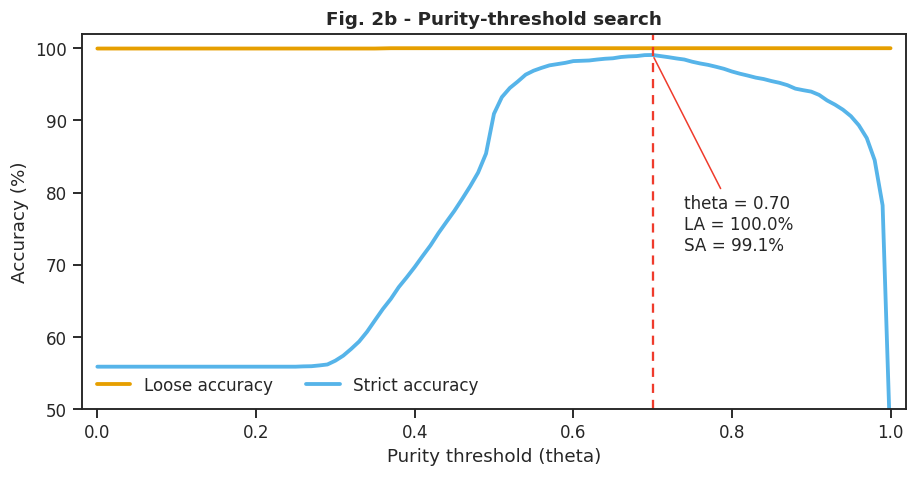

Training samples: 4,593
Selected theta = 0.70; loose = 100.00%; strict = 99.06%


In [3]:
x_train_100 = pd.read_csv(
    REPO_ROOT / "data" / "X_train_SNP_WG_prune_v3_1_std_pca_100.csv",
    index_col="dog_id",
)
y_all_100 = pd.read_csv(REPO_ROOT / "data" / "y_combined_100.csv", index_col="dog_id")
x_train_100.index = x_train_100.index.astype(str)
y_all_100.index = y_all_100.index.astype(str)
y_train_100 = y_all_100.loc[x_train_100.index]

model_100 = joblib.load(REPO_ROOT / "model" / "regressor_model0_4-PCA100.pkl")
y_pred_100 = model_100.predict(x_train_100)

thresholds_100, strict_100, loose_100, _ = threshold_search(y_pred_100, y_train_100)
theta_100 = best_threshold(thresholds_100, strict_100, loose_100)
theta_index = np.flatnonzero(np.isclose(thresholds_100, theta_100))[0]
assert np.isclose(theta_100, 0.70)
assert np.isclose(loose_100[theta_index], 1.0)
assert np.isclose(strict_100[theta_index], 0.9906379272806445)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(thresholds_100, loose_100 * 100, color="#e69f00", linewidth=2.5,
        label="Loose accuracy")
ax.plot(thresholds_100, strict_100 * 100, color="#56b4e9", linewidth=2.5,
        label="Strict accuracy")
ax.axvline(theta_100, color="#ef3b2c", linestyle=(0, (4, 3)), linewidth=1.5)
ax.annotate(
    f"theta = {theta_100:.2f}\nLA = {loose_100[theta_index]:.1%}\nSA = {strict_100[theta_index]:.1%}",
    xy=(theta_100, strict_100[theta_index] * 100),
    xytext=(theta_100 + 0.04, 72),
    arrowprops={"arrowstyle": "-", "color": "#ef3b2c"},
    fontsize=11,
)
ax.set(xlabel="Purity threshold (theta)", ylabel="Accuracy (%)",
       xlim=(-0.02, 1.02), ylim=(50, 102), title="Fig. 2b - Purity-threshold search")
ax.legend(frameon=False, ncol=2, loc="lower left")
fig.tight_layout()
plt.show()

print(f"Training samples: {len(y_train_100):,}")
print(f"Selected theta = {theta_100:.2f}; loose = {loose_100[theta_index]:.2%}; strict = {strict_100[theta_index]:.2%}")

## Fig. 2c: ten-class prediction map

This cell loads `regressor_model0.pkl`, the archived 10-output, 100-feature
forest from `Dog_project`, together with its matching legacy MAF-0.4 100-PC
matrix. It does not substitute the repository's 100-class model and it does
not fit a new estimator.

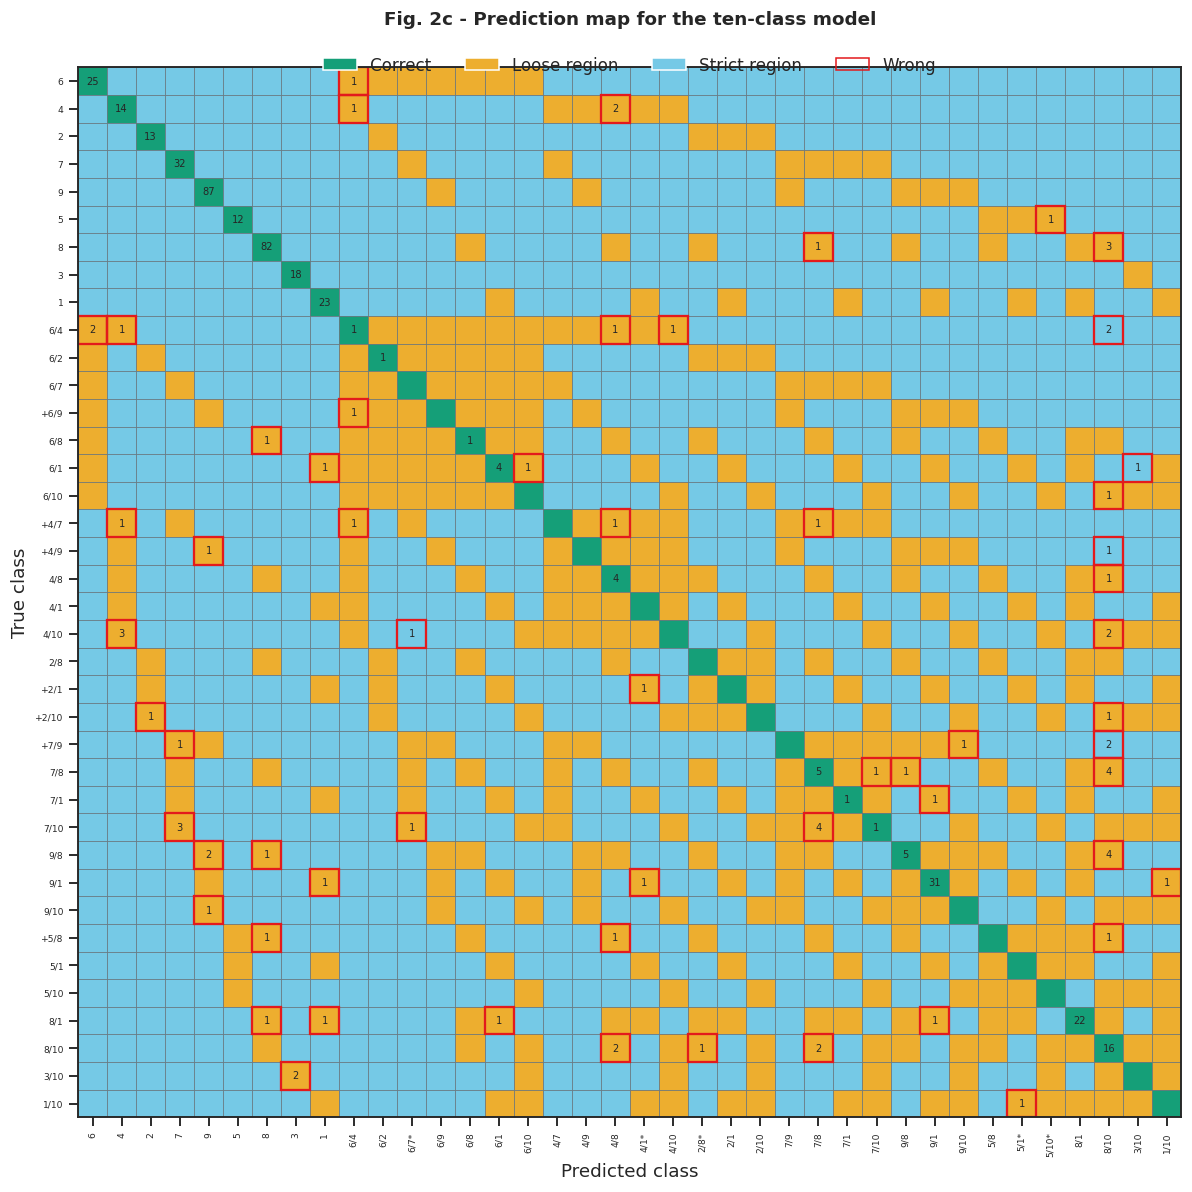

,0,1,2,3,4,5,6,7,8,9
number,1,2,3,4,5,6,7,8,9,10
breed,Poodle,Dachshund,Pembroke Welsh Corgi,Border Collie,Great Dane,Australian Shepherd,German Shepherd Dog,Labrador Retriever,Golden Retriever,Unknown


Legacy PCA dimensions: (7618, 100)
Train/test dimensions: (1921, 100) / (481, 100)
Selected theta = 0.67; loose = 98.54%; strict = 82.74%


In [4]:
y_10 = pd.read_csv(FIGURE_DATA / "fig2c" / "y_combined_10.csv", index_col="dog_id")
x_pca_10 = pd.read_csv(
    FIGURE_DATA / "fig2c" / "X_SNP_WG_prune_v3_1_std_pca_100_legacy.csv",
    index_col="dog_id",
)
y_10.index = y_10.index.astype(str)
x_pca_10.index = x_pca_10.index.astype(str)
y_10.sort_index(inplace=True)
x_pca_10.sort_index(inplace=True)

common_ids = y_10.index.intersection(x_pca_10.index)
x_10 = x_pca_10.loc[common_ids]
y_10 = y_10.loc[common_ids]
x_train_10, x_test_10, y_train_10, y_test_10 = train_test_split(
    x_10, y_10, test_size=0.2, random_state=42
)

model_10 = joblib.load(FIGURE_DATA / "fig2c" / "regressor_model0_4-10.pkl")
assert len(model_10.estimators_) == 10
assert model_10.estimators_[0].n_features_in_ == x_test_10.shape[1] == 100
y_pred_10 = model_10.predict(x_test_10)
thresholds_10, strict_10, loose_10, _ = threshold_search(y_pred_10, y_test_10)
# Use the threshold recorded by the original executed notebook. The available
# model has the same accuracy plateau through theta=0.73, so the automated
# last-tie rule would otherwise select 0.73 instead of the recorded 0.67.
theta_10 = 0.67
strict_acc_10, loose_acc_10, _, metadata_10 = prediction_metrics(
    y_pred_10, y_test_10, theta_10
)
assert np.isclose(strict_acc_10, 0.8274428274428275)
assert np.isclose(loose_acc_10, 0.9854469854469855)

fig, breed_mapping_10 = plot_prediction_map(
    y_test_10, y_pred_10, theta_10, metadata_10,
    "Fig. 2c - Prediction map for the ten-class model",
)
plt.show()
display(breed_mapping_10.T)
print(f"Legacy PCA dimensions: {x_pca_10.shape}")
print(f"Train/test dimensions: {x_train_10.shape} / {x_test_10.shape}")
print(f"Selected theta = {theta_10:.2f}; loose = {loose_acc_10:.2%}; strict = {strict_acc_10:.2%}")

## Fig. 2e: number of test samples per class

Class totals come from the saved 100-class prediction analysis. Purebred and
mixed labels are separated using the same hyphen rule and the two breed-name
exceptions used in the original notebook.

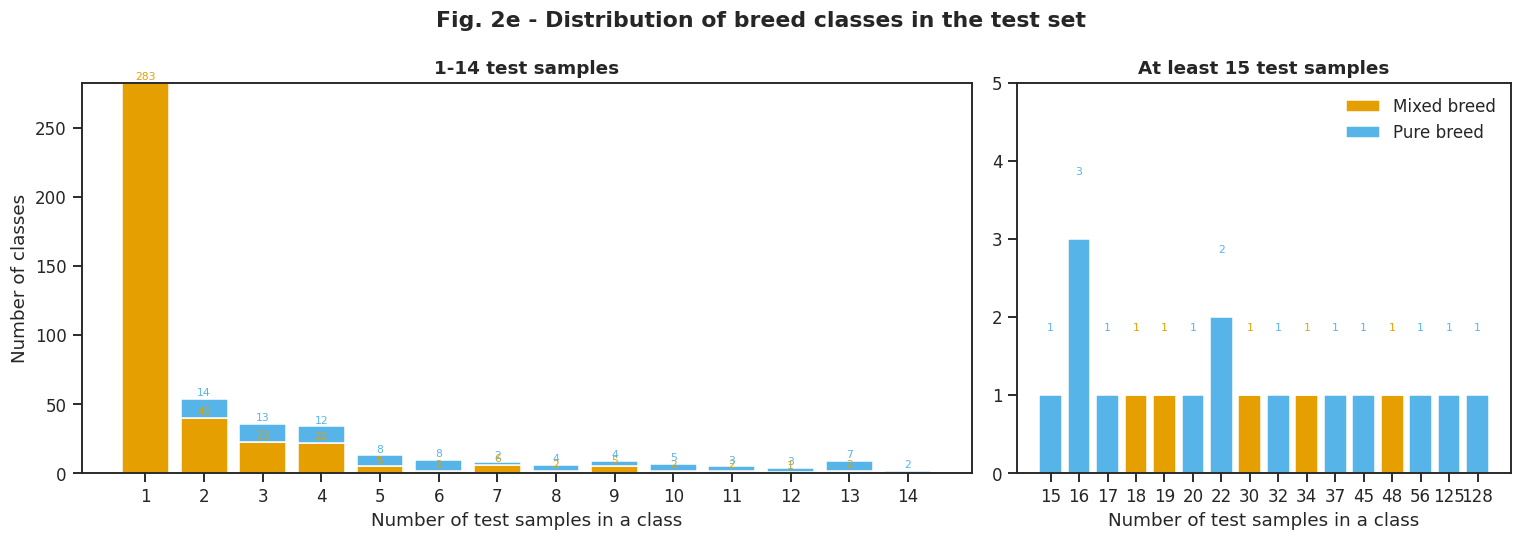

Class labels: 499; test samples represented: 1,979


In [5]:
class_details = pd.read_csv(
    FIGURE_DATA / "fig2e" / "Per_class_prediction_details.csv"
)

def is_mixed_label(label):
    cleaned = str(label).replace("Chinese Shar-Pei", "Chinese Shar Pei")
    cleaned = cleaned.replace("Flat-Coated Retriever", "Flat Coated Retriever")
    return "-" in cleaned

class_details["type"] = np.where(
    class_details["Class Label"].map(is_mixed_label), "Mixed breed", "Pure breed"
)
counts = (
    class_details.groupby(["Total", "type"]).size().unstack(fill_value=0)
    .reindex(columns=["Mixed breed", "Pure breed"], fill_value=0)
    .sort_index()
)
small = counts.loc[counts.index <= 14]
large = counts.loc[counts.index >= 15]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.8, 1]})
colors = {"Mixed breed": "#e69f00", "Pure breed": "#56b4e9"}
for ax, subset, title in zip(
    axes, [small, large], ["1-14 test samples", "At least 15 test samples"]
):
    x = np.arange(len(subset))
    bottom = np.zeros(len(subset))
    for category in ["Mixed breed", "Pure breed"]:
        values = subset[category].to_numpy()
        ax.bar(x, values, bottom=bottom, color=colors[category], label=category)
        for xi, value, base in zip(x, values, bottom):
            if value:
                ax.text(xi, base + value + 0.8, str(int(value)), ha="center",
                        va="bottom", fontsize=7, color=colors[category])
        bottom += values
    ax.set_xticks(x, subset.index.astype(str), rotation=0)
    ax.set_xlabel("Number of test samples in a class")
    ax.set_title(title)
axes[0].set_ylabel("Number of classes")
axes[1].set_ylim(0, 5)
axes[1].legend(frameon=False, loc="upper right")
fig.suptitle("Fig. 2e - Distribution of breed classes in the test set", fontweight="bold")
fig.tight_layout()
plt.show()

print(f"Class labels: {len(class_details):,}; test samples represented: {class_details['Total'].sum():,}")

## Fig. 3b: breed-specific SNP importance by rank

The fourteen saved importance tables already contain the SNP-level projection
from PCA space. Importance is multiplied by `1e5` to match the paper axis.

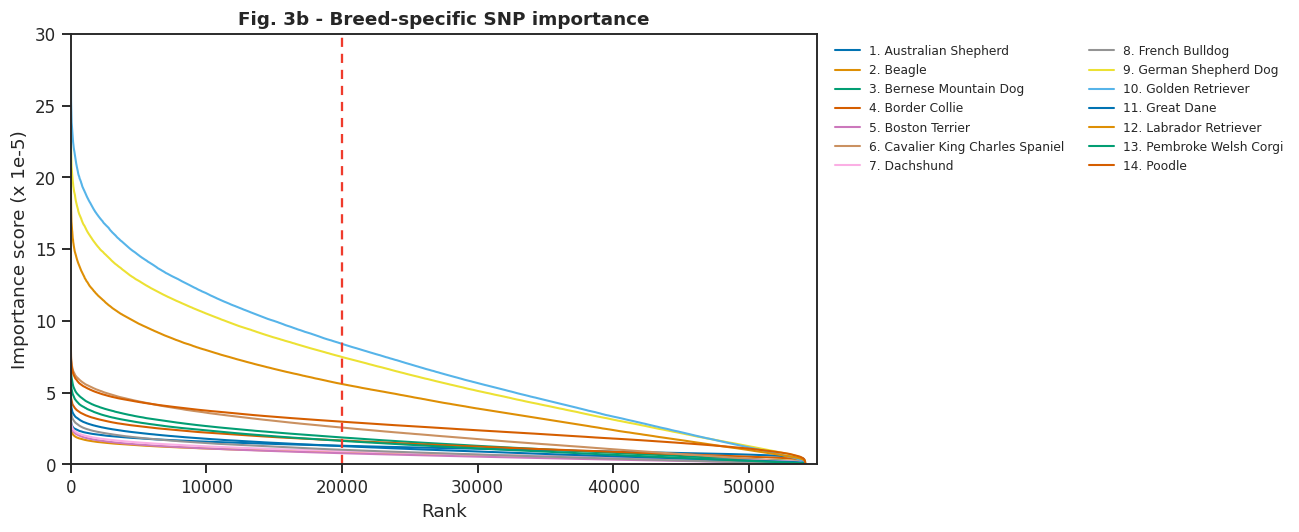

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
number,1,2,3,4,5,6,7,8,9,10,11,12,13,14
breed,Australian Shepherd,Beagle,Bernese Mountain Dog,Border Collie,Boston Terrier,Cavalier King Charles Spaniel,Dachshund,French Bulldog,German Shepherd Dog,Golden Retriever,Great Dane,Labrador Retriever,Pembroke Welsh Corgi,Poodle


In [6]:
importance_dir = FIGURE_DATA / "fig3" / "importance" / "per_breed"
importance_files = sorted(importance_dir.glob("Snp_importance_*.csv"))
if len(importance_files) != 14:
    raise ValueError(f"Expected 14 importance files, found {len(importance_files)}")

importance_tables = []
for path in importance_files:
    table = pd.read_csv(path).sort_values("rank")
    importance_tables.append((table["breed"].iloc[0], table))

palette = sns.color_palette("colorblind", n_colors=14)
fig, ax = plt.subplots(figsize=(12, 5))
for number, ((breed, table), color) in enumerate(zip(importance_tables, palette), start=1):
    ax.plot(table["rank"], table["importance"] * 1e5, color=color,
            linewidth=1.35, label=f"{number}. {breed}")
ax.axvline(20_000, color="#ef3b2c", linestyle=(0, (4, 3)), linewidth=1.5)
ax.set(xlabel="Rank", ylabel="Importance score (x 1e-5)", xlim=(0, 55_000), ylim=(0, 30),
       title="Fig. 3b - Breed-specific SNP importance")
ax.legend(frameon=False, fontsize=8, ncol=2, bbox_to_anchor=(1.01, 1), loc="upper left")
fig.tight_layout()
plt.show()

display(pd.DataFrame({"number": range(1, 15), "breed": [x[0] for x in importance_tables]}).T)

## Fig. 3c: sharing of top- and bottom-ranked SNPs

For each SNP, the saved overlap tables record how many of the fourteen breeds
contain that SNP in their 20,000-SNP rank window.

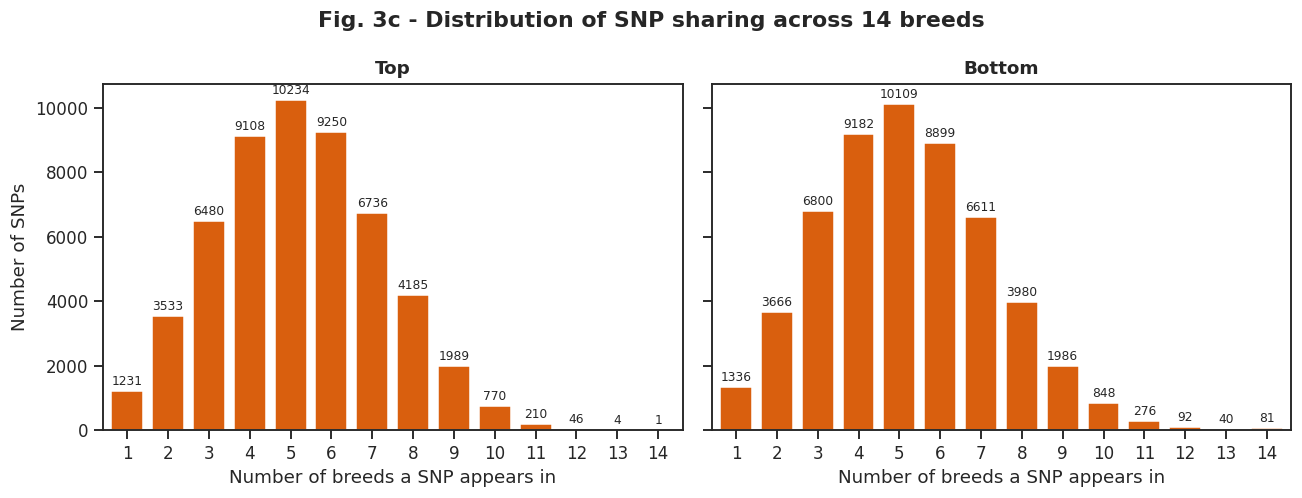

In [7]:
overlap_dir = FIGURE_DATA / "fig3" / "overlap_and_similarity"
overlap_top = pd.read_csv(overlap_dir / "SNP_Overlap_for_Selected_Breeds.csv")
overlap_bottom = pd.read_csv(overlap_dir / "SNP_Overlap_for_Selected_Breeds_Bottom.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, table, title in zip(axes, [overlap_top, overlap_bottom], ["Top", "Bottom"]):
    values = table["num_breeds"].value_counts().reindex(range(1, 15), fill_value=0)
    bars = ax.bar(values.index, values.values, color="#d95f0e", width=0.78)
    ax.bar_label(bars, labels=[f"{value}" for value in values.values], padding=2, fontsize=8)
    ax.set(xlabel="Number of breeds a SNP appears in", title=title,
           xticks=range(1, 15), xlim=(0.4, 14.6))
axes[0].set_ylabel("Number of SNPs")
fig.suptitle("Fig. 3c - Distribution of SNP sharing across 14 breeds", fontweight="bold")
fig.tight_layout()
plt.show()

## Fig. 3d: reduced-SNP prediction

Mean strict and loose accuracies and their standard deviations are read from
the eight saved top/bottom and PCA/no-PCA experiment tables.

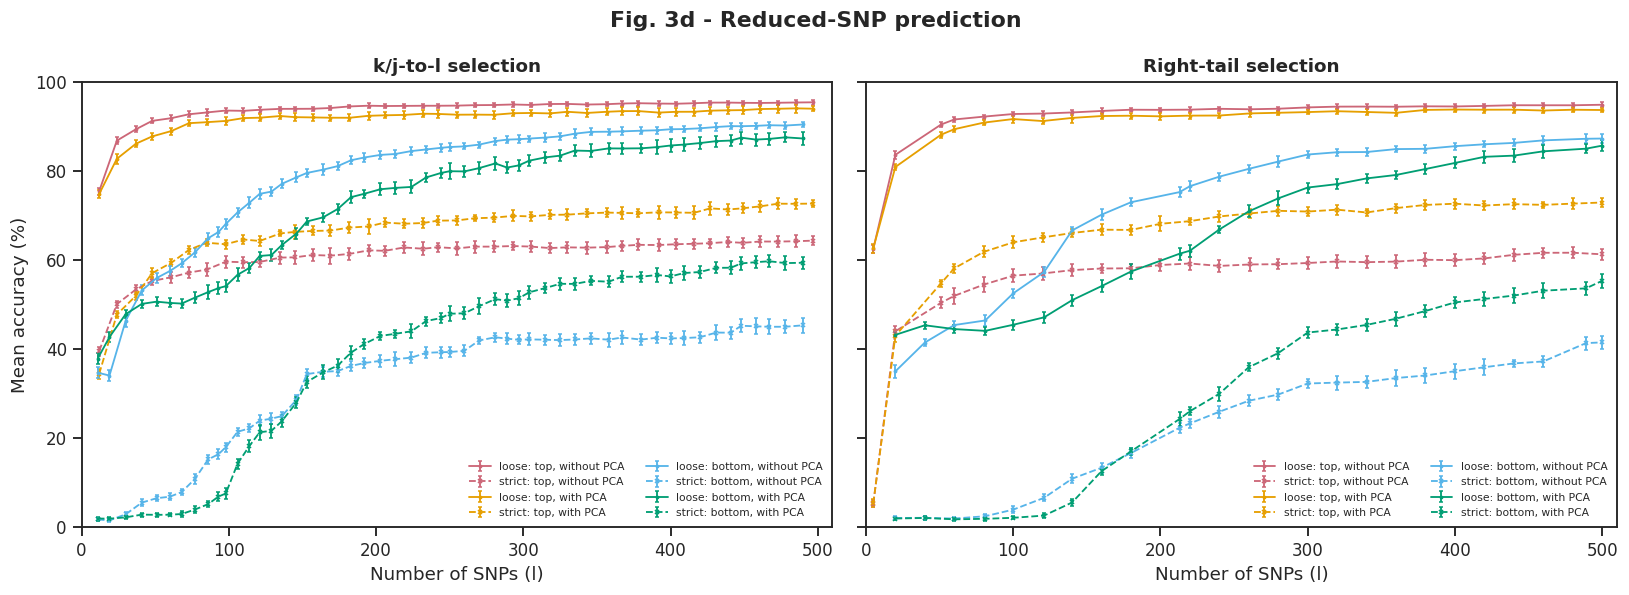

In [8]:
experiment_dir = FIGURE_DATA / "fig3" / "reduced_snp_experiments"
experiment_files = {
    "top_no_pca": "K_to_L_Pureonly_False_PCA_None.csv",
    "top_pca": "K_to_L_Pureonly_False_PCA_0.95.csv",
    "bottom_no_pca": "J_to_L_Pureonly_False_PCA_None_Bottom.csv",
    "bottom_pca": "J_to_L_Pureonly_False_PCA_0.95_Bottom.csv",
    "tail_top_no_pca": "Right_Tail_L_Pureonly_False_PCA_None.csv",
    "tail_top_pca": "Right_Tail_L_Pureonly_False_PCA_0.95.csv",
    "tail_bottom_no_pca": "Right_Tail_L_Pureonly_False_PCA_None_Bottom.csv",
    "tail_bottom_pca": "Right_Tail_L_Pureonly_False_PCA_0.95_Bottom.csv",
}
experiments = {key: pd.read_csv(experiment_dir / name) for key, name in experiment_files.items()}

colors = {"top_no_pca": "#cc6677", "top_pca": "#e69f00",
          "bottom_no_pca": "#56b4e9", "bottom_pca": "#009e73",
          "tail_top_no_pca": "#cc6677", "tail_top_pca": "#e69f00",
          "tail_bottom_no_pca": "#56b4e9", "tail_bottom_pca": "#009e73"}
labels = {
    "top_no_pca": "top, without PCA", "top_pca": "top, with PCA",
    "bottom_no_pca": "bottom, without PCA", "bottom_pca": "bottom, with PCA",
    "tail_top_no_pca": "top, without PCA", "tail_top_pca": "top, with PCA",
    "tail_bottom_no_pca": "bottom, without PCA", "tail_bottom_pca": "bottom, with PCA",
}

def draw_reduced_panel(ax, keys, title):
    for key in keys:
        table = experiments[key]
        for metric, linestyle, marker in [("loose", "-", "."), ("strict", "--", "x")]:
            ax.errorbar(
                table["l"], table[f"{metric}_mean"] * 100,
                yerr=table[f"{metric}_std"] * 100,
                color=colors[key], linestyle=linestyle, marker=marker,
                markersize=3, linewidth=1.2, capsize=1.5,
                label=f"{metric}: {labels[key]}",
            )
    ax.set(title=title, xlabel="Number of SNPs (l)", xlim=(0, 510), ylim=(0, 100))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
draw_reduced_panel(axes[0], ["top_no_pca", "top_pca", "bottom_no_pca", "bottom_pca"],
                   "k/j-to-l selection")
draw_reduced_panel(axes[1], ["tail_top_no_pca", "tail_top_pca", "tail_bottom_no_pca", "tail_bottom_pca"],
                   "Right-tail selection")
axes[0].set_ylabel("Mean accuracy (%)")
for ax in axes:
    ax.legend(frameon=False, fontsize=7, ncol=2, loc="lower right")
fig.suptitle("Fig. 3d - Reduced-SNP prediction", fontweight="bold")
fig.tight_layout()
plt.show()

## Fig. 3e: top/bottom rank-window similarity

The Jaccard index compares the union of SNPs selected from the top and bottom
of each breed-specific ranking as the per-breed rank window grows.

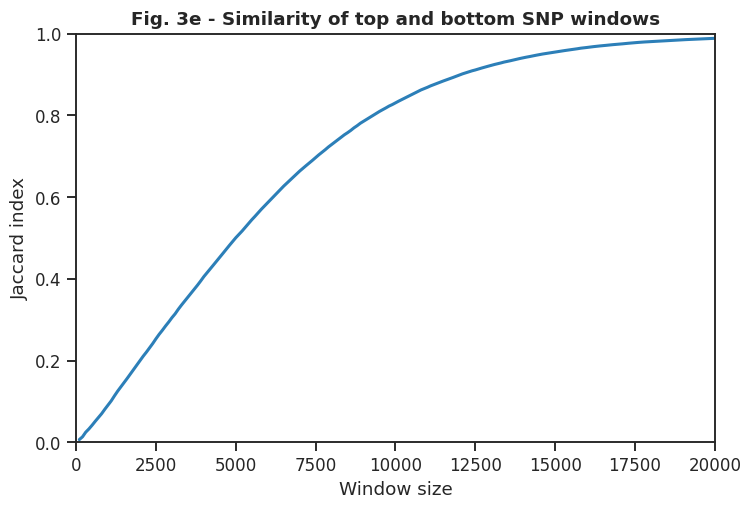

Jaccard index at k=20,000: 0.9889


In [9]:
jaccard = pd.read_csv(overlap_dir / "Top_Bottom_SNP_Jaccard_index.csv")
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(jaccard["k"], jaccard["Jaccard_idx"], color="#2c7fb8", linewidth=2)
ax.set(xlabel="Window size", ylabel="Jaccard index", xlim=(0, 20_000), ylim=(0, 1),
       title="Fig. 3e - Similarity of top and bottom SNP windows")
fig.tight_layout()
plt.show()
print(f"Jaccard index at k=20,000: {jaccard.iloc[-1]['Jaccard_idx']:.4f}")

## Fig. 3f: coverage by expanding top-rank windows

`Coverage.csv` stores 2,000 evaluations corresponding to per-breed top-rank
windows from 10 through 20,000 in increments of 10. The paper panel displays
the first 5,000 ranks.

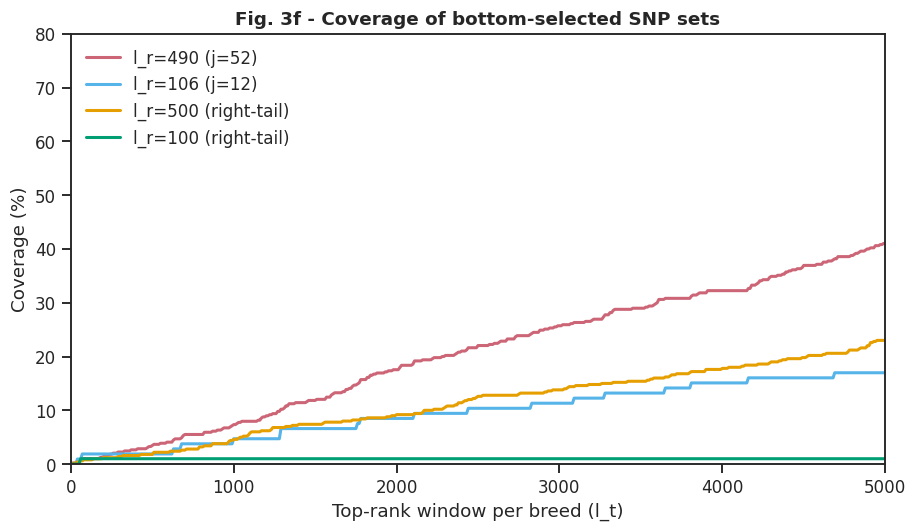

In [10]:
coverage = pd.read_csv(overlap_dir / "Coverage.csv")
coverage = coverage.assign(l_t=np.arange(10, 10 * (len(coverage) + 1), 10))
coverage_plot = coverage.loc[coverage["l_t"] <= 5_000]
coverage_series = [
    ("Y1", "l_r=490 (j=52)", "#cc6677"),
    ("Y2", "l_r=106 (j=12)", "#56b4e9"),
    ("Y3", "l_r=500 (right-tail)", "#e69f00"),
    ("Y4", "l_r=100 (right-tail)", "#009e73"),
]

fig, ax = plt.subplots(figsize=(8.5, 5))
for column, label, color in coverage_series:
    ax.plot(coverage_plot["l_t"], coverage_plot[column] * 100,
            color=color, linewidth=2, label=label)
ax.set(xlabel="Top-rank window per breed (l_t)", ylabel="Coverage (%)",
       xlim=(0, 5_000), ylim=(0, 80), title="Fig. 3f - Coverage of bottom-selected SNP sets")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

## Fig. 3h: SNP rank and average allele frequency

The first panel pools all fourteen breeds. The small panels show each breed
separately. Sample counts are recovered from the genotype-count columns; loose
and strict per-class accuracies are read from the saved 100-class analysis.
The kernel-density grid is reduced to 80 points per axis for practical inline
rendering while retaining all 54,143 SNP observations per breed.

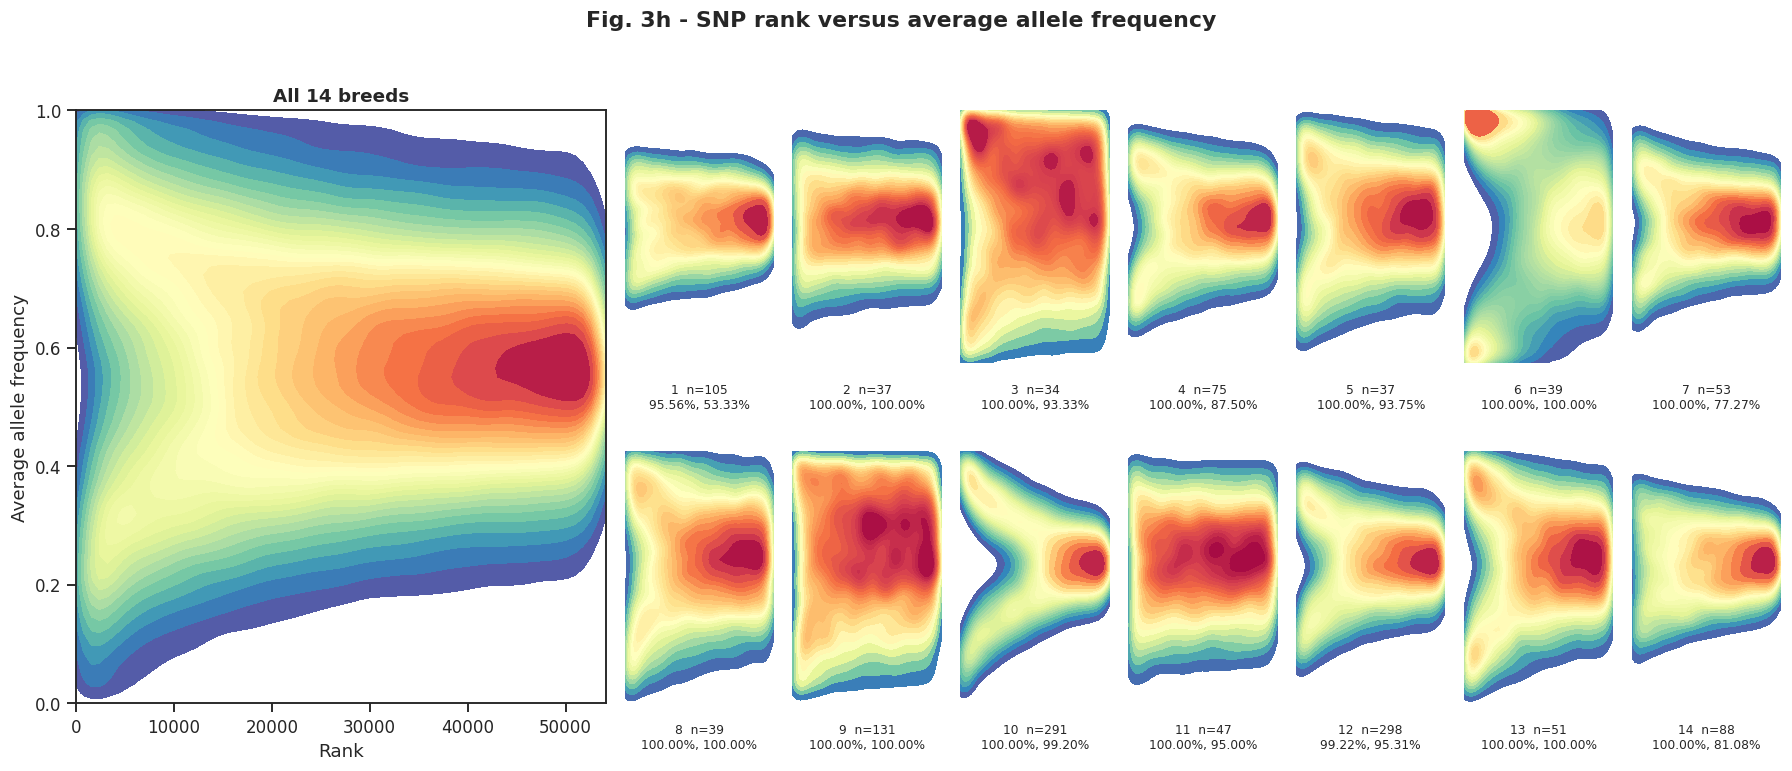

,number,breed,training purebred n
0,1,Australian Shepherd,105
1,2,Beagle,37
2,3,Bernese Mountain Dog,34
3,4,Border Collie,75
4,5,Boston Terrier,37
5,6,Cavalier King Charles Spaniel,39
6,7,Dachshund,53
7,8,French Bulldog,39
8,9,German Shepherd Dog,131
9,10,Golden Retriever,291


In [11]:
frequency_dir = FIGURE_DATA / "fig3" / "importance" / "per_breed_with_frequency"
frequency_files = sorted(frequency_dir.glob("Snp_importance_*.csv"))
if len(frequency_files) != 14:
    raise ValueError(f"Expected 14 frequency tables, found {len(frequency_files)}")

frequency_tables = []
for path in frequency_files:
    table = pd.read_csv(path)
    breed = table["breed"].iloc[0]
    n_dogs = int(table.loc[0, ["snp_count_0", "snp_count_1", "snp_count_2"]].sum())
    frequency_tables.append((breed, n_dogs, table))
all_frequencies = pd.concat([table for _, _, table in frequency_tables], ignore_index=True)
accuracy_by_class = class_details.set_index("Class Label")

fig = plt.figure(figsize=(20, 7))
grid = fig.add_gridspec(2, 10, width_ratios=[1.1, 1.1, 1.1] + [1] * 7,
                        wspace=0.12, hspace=0.35)
overall_ax = fig.add_subplot(grid[:, :3])
sns.kdeplot(
    data=all_frequencies, x="rank", y="avg_allele_freq", fill=True,
    levels=30, gridsize=80, cmap="Spectral_r", ax=overall_ax,
    warn_singular=False,
)
overall_ax.set(xlabel="Rank", ylabel="Average allele frequency", xlim=(0, 54_143), ylim=(0, 1))
overall_ax.set_title("All 14 breeds")

for number, (breed, n_dogs, table) in enumerate(frequency_tables, start=1):
    row = (number - 1) // 7
    col = 3 + (number - 1) % 7
    ax = fig.add_subplot(grid[row, col])
    sns.kdeplot(
        data=table, x="rank", y="avg_allele_freq", fill=True,
        levels=24, gridsize=80, cmap="Spectral_r", ax=ax,
        warn_singular=False,
    )
    ax.set(xlim=(0, 54_143), ylim=(0, 1))
    ax.axis("off")
    if breed in accuracy_by_class.index:
        result = accuracy_by_class.loc[breed]
        score_text = f"{result['Loose Accuracy']:.2%}, {result['Strict Accuracy']:.2%}"
    else:
        score_text = "not available"
    ax.text(0.5, -0.08, f"{number}  n={n_dogs}\n{score_text}",
            transform=ax.transAxes, ha="center", va="top", fontsize=8)

fig.suptitle("Fig. 3h - SNP rank versus average allele frequency", fontweight="bold", y=1.01)
plt.show()

summary_3h = pd.DataFrame({
    "number": range(1, 15),
    "breed": [breed for breed, _, _ in frequency_tables],
    "training purebred n": [n for _, n, _ in frequency_tables],
})
display(summary_3h)

## Reproduction status

All requested panels were evaluated in this run. Their rendered outputs are
stored directly in this notebook. Re-running the notebook does not create any
PNG, SVG, or PDF files.